# 12. Stability Measuring

Avaliação de **estabilidade** (robustez a ruído contínuo) das explicações locais **LIME** e **SHAP** via perturbações intencionais nos atributos contínuos.


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))

from src.utils.helpers import load_pickle
from src.evaluation.stability import perturb_instance, calculate_stability

from src.explainers.shap_explainer import create_explainer as create_shap_explainer, explain_instance as explain_shap_instance
from src.explainers.lime_explainer import create_lime_explainer, create_predict_fn, transform_instance_for_lime, explain_instance as explain_lime_instance

c:\Users\anderson\Downloads\GIT\demand-forecast-xai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
#Load model and data
artifact_dir = Path('../experiments/exp_001_lgbm/artifacts')

store_filter = ['CA_1', 'TX_1']
if isinstance(store_filter, (list, tuple, set, pd.Index)):
    store_suffix = '_'.join(map(str, store_filter))
else:
    store_suffix = store_filter if store_filter else 'all_stores'

model_path = artifact_dir / f'lightgbm_{store_suffix}.pkl'
model = load_pickle(model_path)

x_train_path = artifact_dir / f"X_train_{store_suffix}.parquet"
X_train = pd.read_parquet(x_train_path)

x_test_path = artifact_dir / f'X_test_predict_{store_suffix}.parquet'
X_test = pd.read_parquet(x_test_path)

shap_path = artifact_dir / f"shap_explanation_{store_suffix}.parquet"
shap_explanations = pd.read_parquet(shap_path)

lime_path = artifact_dir / f"lime_explanations_{store_suffix}.parquet"
lime_explanations = pd.read_parquet(lime_path)

sample_path = artifact_dir / f'sample_{store_suffix}.parquet'
selected_predictions = pd.read_parquet(sample_path)

#Config
random_state = 42
n_runs = 10
perturbation_pct = 0.01
num_samples = 5000

categorical_cols = [
    "item_id",
    "dept_id",
    "cat_id",
    "store_id",
    "state_id",
    "event_name_1",
    "event_type_1",
    "event_name_2",
    "event_type_2",
]

numeric_features = [
    "sell_price",
    "sales_lag_7",
    "sales_lag_28",
    "rolling_mean_7",
    "rolling_mean_28",
    "rolling_mean_7_sales_lag_28",
    "rolling_mean_28_sales_lag_28",
]

Loaded from ..\experiments\exp_001_lgbm\artifacts\lightgbm_CA_1_TX_1.pkl


In [4]:
#Config Lime

lime_explainer, X_train_lime, lime_metadata = create_lime_explainer(
    X_train=X_train,
    categorical_cols=categorical_cols,
    random_state=random_state,
)

predict_fn = create_predict_fn(
    model=model,
    metadata=lime_metadata,
)

In [5]:
#Config SHAP

shap_explainer = create_shap_explainer(
    model
)

In [6]:
results = []

instance_ids = sorted(
    shap_explanations["instance_id"].unique()
)


for instance_id in instance_ids:

    original_instance = X_test.iloc[[instance_id]].copy()

    original_shap = shap_explanations[
        shap_explanations["instance_id"]
        == instance_id
    ]

    original_lime = lime_explanations[
        lime_explanations["instance_id"]
        == instance_id
    ]


    for run in range(n_runs):

        seed = (
            random_state
            + instance_id * n_runs
            + run
        )


        # -----------------------------
        # Perturbation
        # -----------------------------

        perturbed_instance = perturb_instance(
            instance=original_instance,
            numeric_features=numeric_features,
            perturbation_pct=perturbation_pct,
            random_state=seed,
        )


        # =============================
        # SHAP
        # =============================

        shap_perturbed = explain_shap_instance(
            explainer=shap_explainer,
            instance=perturbed_instance,
            instance_id=instance_id,
        )

        shap_stability = calculate_stability(
            original_explanation=original_shap,
            perturbed_explanation=shap_perturbed,
        )

        results.append({
            "instance_id": instance_id,
            "method": "SHAP",
            "run": run,
            "stability": shap_stability,
        })


        # =============================
        # LIME
        # =============================

        lime_instance = perturbed_instance.iloc[0]

        instance_lime = transform_instance_for_lime(
            instance=lime_instance,
            metadata=lime_metadata,
        )

        _, lime_perturbed = explain_lime_instance(
            explainer=lime_explainer,
            predict_fn=predict_fn,
            instance=lime_instance,
            instance_lime=instance_lime,
            instance_id=instance_id,
            num_samples=num_samples,
        )

        lime_stability = calculate_stability(
            original_explanation=original_lime,
            perturbed_explanation=lime_perturbed,
        )

        results.append({
            "instance_id": instance_id,
            "method": "LIME",
            "run": run,
            "stability": lime_stability,
        })

In [7]:
stability_results = pd.DataFrame(
    results
)

stability_results.head()

,instance_id,method,run,stability
0,1919,SHAP,0,1.000000
1,1919,LIME,0,0.704119
2,1919,SHAP,1,1.000000
3,1919,LIME,1,0.625138
4,1919,SHAP,2,1.000000


In [8]:
stability_summary = (
    stability_results
    .groupby("method")["stability"]
    .agg(
        mean="mean",
        std="std",
        median="median",
    )
    .reset_index()
)

stability_summary

,method,mean,std,median
0,LIME,0.694703,0.141569,0.69904
1,SHAP,0.999098,0.003805,1.00000


In [9]:
stability_by_instance = (
    stability_results
    .groupby(
        [
            "method",
            "instance_id",
        ]
    )["stability"]
    .agg(
        mean="mean",
        std="std",
    )
    .reset_index()
)

stability_by_instance.head()

,method,instance_id,mean,std
0,LIME,1919,0.687950,0.044397
1,LIME,2530,0.713086,0.040870
2,LIME,3326,0.715146,0.038080
3,LIME,4157,0.463418,0.035536
4,LIME,4494,0.498741,0.024948


In [10]:
stability_results.to_parquet(
    artifact_dir
    / f"stability_results_{store_suffix}.parquet",
    index=False,
)

stability_summary.to_parquet(
    artifact_dir
    / f"stability_summary_{store_suffix}.parquet",
    index=False,
)

stability_by_instance.to_parquet(
    artifact_dir
    / f"stability_by_instance_{store_suffix}.parquet",
    index=False,
)

# Analysis

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

stability_results = pd.read_parquet(artifact_dir / f"stability_results_{store_suffix}.parquet")
stability_summary = pd.read_parquet(artifact_dir / f"stability_summary_{store_suffix}.parquet")
stability_by_instance = pd.read_parquet(artifact_dir / f"stability_by_instance_{store_suffix}.parquet")



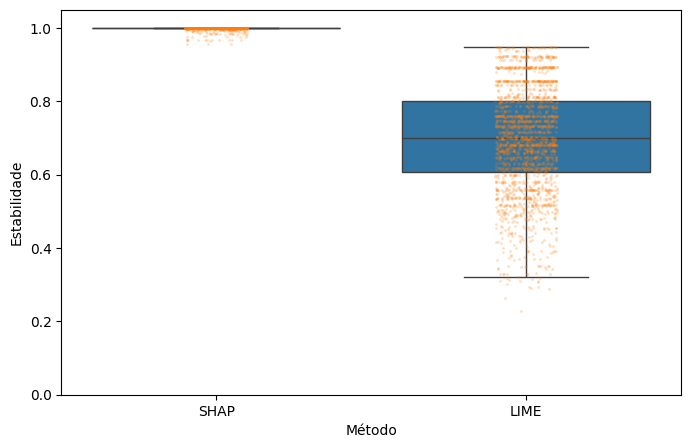

In [13]:


plt.figure(figsize=(8, 5))

sns.boxplot(
    data=stability_results,
    x='method',
    y='stability',
    showfliers=False
)

sns.stripplot(
    data=stability_results,
    x='method',
    y='stability',
    alpha=0.25,
    size=2
)

plt.xlabel('Método')
plt.ylabel('Estabilidade')
plt.ylim(0, 1.05)

plt.show()

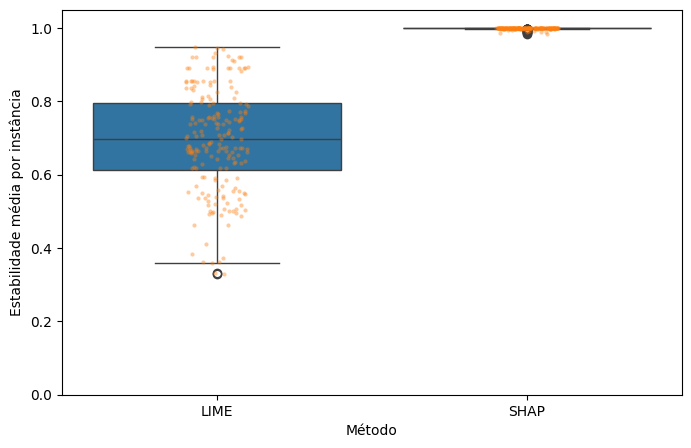

In [14]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=stability_by_instance,
    x='method',
    y='mean'
)

sns.stripplot(
    data=stability_by_instance,
    x='method',
    y='mean',
    alpha=0.4,
    size=3
)

plt.xlabel('Método')
plt.ylabel('Estabilidade média por instância')
plt.ylim(0, 1.05)

plt.show()

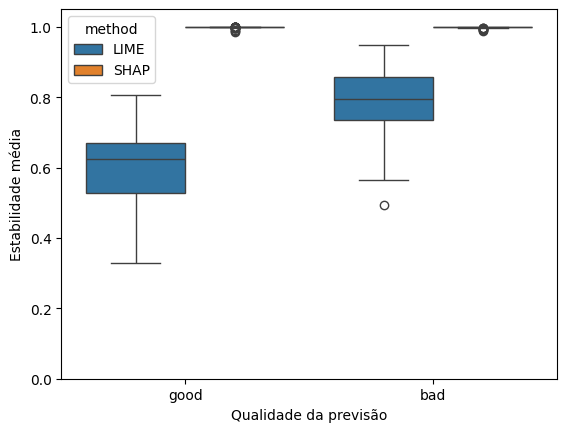

In [16]:
stability_analysis = stability_by_instance.merge(
    selected_predictions[
        [
            'instance_id',
            'prediction_quality',
            'absolute_error',
            'error_direction'
        ]
    ],
    on='instance_id',
    how='left'
)

sns.boxplot(
    data=stability_analysis,
    x='prediction_quality',
    y='mean',
    hue='method'
)

plt.xlabel('Qualidade da previsão')
plt.ylabel('Estabilidade média')
plt.ylim(0, 1.05)

plt.show()

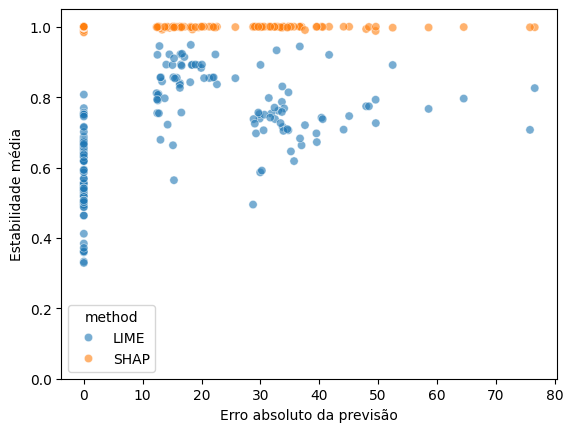

In [17]:
sns.scatterplot(
    data=stability_analysis,
    x='absolute_error',
    y='mean',
    hue='method',
    alpha=0.6
)

plt.xlabel('Erro absoluto da previsão')
plt.ylabel('Estabilidade média')
plt.ylim(0, 1.05)

plt.show()

In [19]:
from scipy.stats import spearmanr

for method in ['SHAP', 'LIME']:
    df_method = stability_analysis[
        stability_analysis['method'] == method
    ]

    rho, p_value = spearmanr(
        df_method['absolute_error'],
        df_method['mean']
    )

    print(
        method,
        'rho =', round(rho, 3),
        'p =', round(p_value, 4)
    )

SHAP rho = -0.299 p = 0.0
LIME rho = 0.561 p = 0.0


In [20]:
lime_worst = (
    stability_by_instance
    .query("method == 'LIME'")
    .sort_values('mean')
    .head(10)
)

lime_worst

,method,instance_id,mean,std
160,LIME,149417,0.328997,0.036110
65,LIME,62249,0.332755,0.052185
111,LIME,108416,0.359173,0.036211
155,LIME,144982,0.361173,0.034452
102,LIME,97688,0.362896,0.044473
161,LIME,150628,0.371601,0.046302
150,LIME,139221,0.384046,0.038566
148,LIME,137348,0.411924,0.040609
3,LIME,4157,0.463418,0.035536
62,LIME,59612,0.463719,0.031160


In [22]:
prediction_info = selected_predictions[
    [
        'instance_id',
        'id',
        'date',
        'y_true',
        'y_pred',
        'absolute_error',
        'error_direction',
        'prediction_quality'
    ]
]

stability_analysis = stability_by_instance.merge(
    prediction_info,
    on='instance_id',
    how='left'
)

stability_analysis.head()

,method,instance_id,mean,std,id,date,y_true,y_pred,absolute_error,error_direction,prediction_quality
0,LIME,1919,0.687950,0.044397,FOODS_3_347_TX_1,2016-04-25,2,2.000245,0.000245,over,good
1,LIME,2530,0.713086,0.040870,FOODS_3_653_CA_1,2016-04-25,2,1.999894,0.000106,under,good
2,LIME,3326,0.715146,0.038080,HOBBIES_1_234_CA_1,2016-04-25,36,2.199713,33.800287,under,bad
3,LIME,4157,0.463418,0.035536,HOUSEHOLD_1_079_TX_1,2016-04-25,1,0.999910,0.000090,under,good
4,LIME,4494,0.498741,0.024948,HOUSEHOLD_1_251_CA_1,2016-04-25,1,0.999023,0.000977,under,good


In [24]:
stability_analysis.groupby(
    ['method', 'prediction_quality']
)['mean'].agg(
    ['mean', 'std', 'median']
)

mean       std    median
method prediction_quality                              
LIME   bad                 0.792910  0.093477  0.794388
       good                0.596496  0.105363  0.624766
SHAP   bad                 0.998908  0.002033  0.999548
       good                0.999288  0.002374  1.000000